# Lab Assignment 1 - Scientific Computing Lab

## Submitted by - Naman Jain, SC26M013

Maximum Camber is:  0.02
Location of Maximum Camber is:  0.3
Maximum Thickness is:  0.14
Maximum Error by Langrange Interpolation is:  0.005458636923629431
RMS Error by Langrange Interpolation is:  0.0011084204411134792
Maximum Error by Cubic Spline Interpolation is:  0.006496295816637238
RMS Error by Cubic Spline Interpolation is:  0.001208765468769014


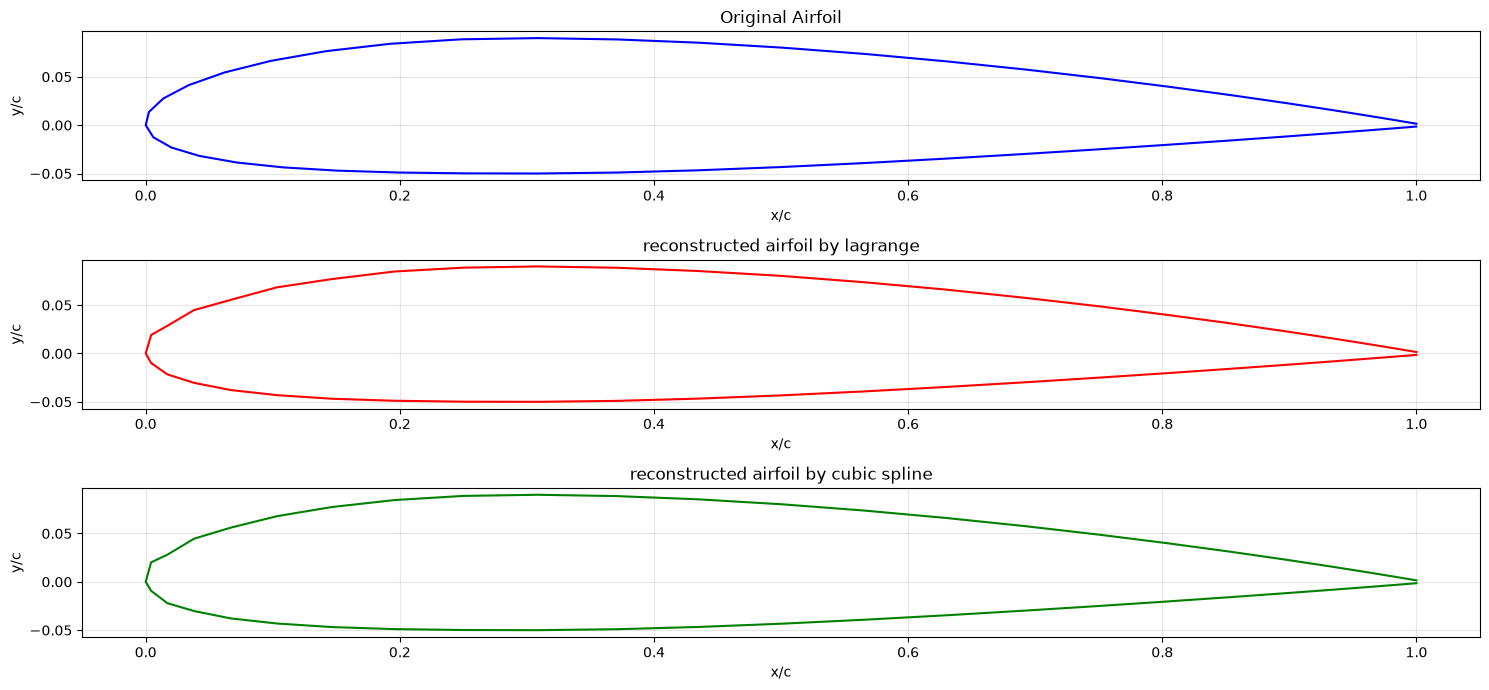

In [15]:
## LANGRANGE FUNCTION EVALUATION FOR A NACA-4-DIGIT CAMBERED AIRFOIL
## REFERENCE CHORD - 1m

import numpy as np
import matplotlib.pyplot as plt

# Airfoil Plotting
a = 25     ## Number of points for plotting 
beta = np.linspace(0, np.pi, a)
x = 0.5 * (1 - np.cos(beta))

m = np.random.randint(2, 5) / 100       # Maximum Camber
p = np.random.randint(2, 8) / 10        # Location of Maximum Camber
t = np.random.randint(10, 25) / 100     # Maximum Thickness

#Initiate arrays
y_t = np.zeros(len(x))
y_c = np.zeros(len(x))
dyc_dx = np.zeros(len(x))
theta = np.zeros(len(x))
x_u = np.zeros(len(x))
x_l = np.zeros(len(x))
y_u = np.zeros(len(x))
y_l = np.zeros(len(x))
y_reconstructed_u = np.zeros(len(x))
y_reconstructed_l = np.zeros(len(x))
y_reconstructed_u_1 = np.zeros(len(x))
y_reconstructed_l_1 = np.zeros(len(x))

#Original Airfoil Generation 
for i in range(len(x)):
    y_t[i] = 5*t*(0.2969*(x[i]**0.5)        # Thickness distribution
               - 0.1260*x[i]
               - 0.3516*(x[i]**2)
               + 0.2843*(x[i]**3)
               - 0.1015*(x[i]**4))

    if 0 <= x[i] <= p:                      # Camber line and slope
        y_c[i] = (m / p**2) * (2*p*x[i] - x[i]**2)
        dyc_dx[i] = (2*m / p**2) * (p - x[i])

    elif p < x[i] <= 1:
        y_c[i] = (m / (1-p)**2) * ((1 - 2*p) + 2*p*x[i] - x[i]**2)
        dyc_dx[i] = (2*m / (1-p)**2) * (p - x[i])
        
    theta[i] = np.arctan(dyc_dx[i])         # Angle of camber line
    
    x_u[i] = x[i] - y_t[i]*np.sin(theta[i]) # Upper and lower surfaces
    x_l[i] = x[i] + y_t[i]*np.sin(theta[i])
    y_u[i] = y_c[i] + y_t[i]*np.cos(theta[i])
    y_l[i] = y_c[i] - y_t[i]*np.cos(theta[i])

# Combine upper and lower surfaces
x_full = np.concatenate((x_u[::-1], x_l))
y_full = np.concatenate((y_u[::-1], y_l))

## LANGRANGE DEFINING 
## xx is reference variable
def lagran(x, y, xx = 0.7):
    n = len(x)
    sum = 0
    for i in range(n):
        product = y[i]
        for j in range(n):
            if i != j:
                 product = product * (xx - x[j]) / (x[i] - x[j])
        sum = sum + product
    lagran = sum
    return lagran

for k in range(len(x)):
    y_reconstructed_u[k] = lagran(x_u, y_u, x[k])
    y_reconstructed_l[k] = lagran(x_l, y_l, x[k])

x_full_reconstructed = np.concatenate((x[::-1], x))
y_full_reconstructed = np.concatenate((y_reconstructed_u[::-1], y_reconstructed_l))

## CUBIC SPLINE INTERPOLATION FUNCTION EVALUATION FOR A NACA-4-DIGIT CAMBERED AIRFOIL
def cubic_spline(x, y, xx):
    n = len(x)
    h = np.diff(x)

    A = np.zeros((n, n))
    rhs = np.zeros(n)

    ## Boundary Condition M_0, M_n = 0 
    A[0, 0] = 1
    A[-1, -1] = 1

    for i in range(1, n - 1):
        A[i, i - 1] = h[i - 1]
        A[i, i] = 2 * (h[i - 1] + h[i])
        A[i, i + 1] = h[i]

        rhs[i] = 6 * (
            (y[i + 1] - y[i]) / h[i]
            - (y[i] - y[i - 1]) / h[i - 1]
        )

    M = np.linalg.solve(A, rhs)

    ## Vectorized interpolation
    indices = np.searchsorted(x, xx, side="right") - 1
    indices = np.clip(indices, 0, n - 2)

    xi = x[indices]
    xi1 = x[indices + 1]

    yi = y[indices]
    yi1 = y[indices + 1]

    hi = h[indices]

    Mi = M[indices]
    Mi1 = M[indices + 1]

    yy = (Mi * (xi1 - xx)**3 / (6 * hi)
          + Mi1 * (xx - xi)**3 / (6 * hi)
          + (yi - Mi * hi**2 / 6) * (xi1 - xx) / hi
          + (yi1 - Mi1 * hi**2 / 6) * (xx - xi) / hi)

    return yy
    
y_reconstructed_u_1 = cubic_spline(x_u, y_u, x)
y_reconstructed_l_1 = cubic_spline(x_l, y_l, x)     

x_full_reconstructed_1 = np.concatenate((x[::-1], x))
y_full_reconstructed_1 = np.concatenate((y_reconstructed_u_1[::-1], y_reconstructed_l_1))

## Calculating Maximum and RMS Errors 
max_error_1 = np.max(np.abs(y_full - y_full_reconstructed))
rms_error_1 = np.sqrt(np.mean((y_full - y_full_reconstructed)**2))
max_error_2 = np.max(np.abs(y_full - y_full_reconstructed_1))
rms_error_2 = np.sqrt(np.mean((y_full - y_full_reconstructed_1)**2))

print("Maximum Camber is: ", m)
print("Location of Maximum Camber is: ", p)
print("Maximum Thickness is: ", t)
print("Maximum Error by Langrange Interpolation is: ", max_error_1)
print("RMS Error by Langrange Interpolation is: ", rms_error_1)
print("Maximum Error by Cubic Spline Interpolation is: ", max_error_2)
print("RMS Error by Cubic Spline Interpolation is: ", rms_error_2)
                      
#PLots
fig, ax = plt.subplots(3, 1, figsize=(15, 7))
ax[0].plot(x_full, y_full, 'b-')
ax[0].set_xlabel('x/c')
ax[0].set_ylabel('y/c')
ax[0].set_title('Original Airfoil')
ax[0].grid(alpha=0.3)

ax[1].plot(x_full_reconstructed, y_full_reconstructed, 'r-')
ax[1].set_xlabel('x/c')
ax[1].set_ylabel('y/c')
ax[1].set_title('reconstructed airfoil by lagrange')
ax[1].grid(alpha=0.3)

ax[2].plot(x_full_reconstructed_1, y_full_reconstructed_1, 'g-')
ax[2].set_xlabel('x/c')
ax[2].set_ylabel('y/c')
ax[2].set_title('reconstructed airfoil by cubic spline')
ax[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Analysis on NACA 4 Digit Cambered Airfoil using Lagrange and Cubic Spline Interpolation

## Problem Statement
### Lab Work: Lagrange Interpolation
Write a Python function to implement **Lagrange interpolation** for a given set of data points. The function should evaluate the interpolated value at specified points.

The implementation must be verified by comparing its results with the polynomial obtained using `scipy.interpolate.lagrange`.

### Comprehensive Work: Airfoil Surface Reconstruction
Choose a cambered NACA 4-digit airfoil of the form **NACA-abcd**. For a given number of points \(N\) along the airfoil geometry, reconstruct a smooth representation of the airfoil surface using interpolation techniques.

The following tasks are to be completed:

1. Use NumPy's random number generator to select the maximum camber, the location of maximum camber, and the thickness-to-chord ratio of the airfoil.
2. Generate the original airfoil geometry using the selected NACA parameters.
3. Use the self-implemented `Lagrng()` function to reconstruct the airfoil surface.
4. Plot the original airfoil geometry and the reconstructed airfoil on the same figure.
5. Quantify the reconstruction error using:
   - Maximum error
   - Root Mean Square (RMS) error
6. Investigate how the choice of spacing between data points affects the reconstruction accuracy, and document methods for improving the results through appropriate point spacing.
7. Reconstruct the airfoil using **cubic spline interpolation** by implementing a Python function for cubic spline interpolation.
8. Compare the cubic spline reconstruction with the original airfoil and quantify the corresponding maximum and RMS errors.

### Idea of Implementation
1. Plot the airfoil using **cosine-spacing** for better accuracy and plotting.
2. Construct the formulas for cambered airfoils using equations for maximum camber and thickness. This is the original airfoil.
3. Define the **langrange function** and using it generate array of points for upper and lower surfaces of the airfoil.
4. Define the **Cubic Spline function** and using it generate array of points for upper and lower surfaces of the airfoil.
5. Concatenate the generated lower and upper surface arrays to get the complete the whole airfoil.
6. Compute the errors by comparing the original and reconstructed airfoils using interpolation using **max** and **rms** values.
7. Finally, Plot the Airfoils.

### NACA 4 Digit Airfoil Construction - Explained
A cambered NACA 4-digit airfoil is generated using the selected maximum camber, location of maximum camber, and maximum thickness parameters. The airfoil geometry is defined using cosine-spaced points along the chord.

#### 1.1 Cosine Spacing
To distribute the points along the chord, the angular coordinate is defined as

$$\beta_i = \frac{\pi}{N}, \qquad i = 1,\ldots,N $$

The chordwise coordinate is then calculated using cosine spacing:

$$x_i = \frac{1}{2}\left(1-\cos\beta_i\right)$$

where \(x_i\) is normalized by the chord, such that \(0 \leq x_i \leq 1\).

#### 1.2 NACA Airfoil Parameters
The NACA 4-digit airfoil is defined using three primary geometric parameters:

- \(m\): Maximum camber as a fraction of the chord.
- \(p\): Location of maximum camber as a fraction of the chord.
- \(t\): Maximum thickness as a fraction of the chord.

In the implementation, these parameters are selected randomly using NumPy:
```python
m = np.random.randint(2, 5) / 100
p = np.random.randint(2, 8) / 10
t = np.random.randint(10, 25) / 100
```
#### 1.3 Thickness Distribution
The thickness distribution of the NACA airfoil is given by

$$
y_t(x) =
5t\left[
0.2969\sqrt{x}
-0.1260x
-0.3516x^2
+0.2843x^3
-0.1015x^4
\right]
$$

where \(y_t(x)\) represents the half-thickness distribution about the camber line.

#### 1.4 Camber Line
The camber line is defined piecewise based on the location of maximum camber \(p\).

For the forward portion, \(0 \leq x \leq p\),
$$
y_c(x) =
\frac{m}{p^2}
\left(2px-x^2\right)
$$

For the rear portion, \(p < x \leq 1\),

$$
y_c(x) =
\frac{m}{(1-p)^2}
\left[
(1-2p)+2px-x^2
\right]
$$

#### 1.5 Camber Line Slope
The derivative of the camber line is used to determine the local inclination of the airfoil surface.
For \(0 \leq x \leq p\),

$$\frac{dy_c}{dx} =
\frac{2m}{p^2}(p-x)
$$

For \(p < x \leq 1\),

$$\frac{dy_c}{dx} =
\frac{2m}{(1-p)^2}(p-x)
$$

#### 1.6 Camber Line Angle
The local angle of the camber line is calculated as

$$
\theta(x) =
\tan^{-1}\left(\frac{dy_c}{dx}\right)
$$

In Python, this is implemented using
```python
theta[i] = np.arctan(dyc_dx[i])
```

#### 1.7 Upper and Lower Surface Coordinates
The upper and lower surface coordinates are obtained by offsetting the thickness distribution normal to the camber line.
The upper surface is given by

$$
x_u = x-y_t\sin\theta
$$

$$
y_u = y_c+y_t\cos\theta
$$

The lower surface is given by

$$
x_l = x+y_t\sin\theta
$$

$$
y_l = y_c-y_t\cos\theta
$$

These equations account for the local slope of the camber line while positioning the thickness above and below it.

#### 1.8 Combining the Airfoil Surfaces
The upper surface is reversed so that the coordinates proceed from the trailing edge toward the leading edge, while the lower surface proceeds from the leading edge toward the trailing edge.

The complete airfoil coordinates are obtained by concatenating the two surfaces:

$$
x_{\text{full}} =
\left[
x_u^{\text{rev}},\ x_l
\right]
$$

$$
y_{\text{full}} =
\left[
y_u^{\text{rev}},\ y_l
\right]
$$

In Python:
```python
x_full = np.concatenate((x_u[::-1], x_l))
y_full = np.concatenate((y_u[::-1], y_l))
```
The resulting arrays represent the complete closed airfoil geometry and can be used for plotting and subsequent interpolation.

### Langrange Interpolation - Explained 
#### 2.1 Theory
Lagrange interpolation is a polynomial interpolation method used to estimate the value of a function at a desired point using a known set of data points.

Given \(n\) data points,

$$
(x_0,y_0),(x_1,y_1),\ldots,(x_{n-1},y_{n-1})
$$

the interpolating polynomial is constructed such that it passes exactly through all the given data points.
The Lagrange interpolating polynomial is defined as

$$
P_{n-1}(x) = \sum_{i=0}^{n-1} y_i L_i(x)
$$

where \(L_i(x)\) is the \(i\)-th Lagrange basis polynomial.

#### 2.2 Lagrange Basis Polynomial
The basis polynomial corresponding to the \(i\)-th data point is

$$
L_i(x) =
\prod_{\substack{j=0\\j\neq i}}^{n-1}
\frac{x-x_j}{x_i-x_j}
$$

The basis polynomials have the important property

$$
L_i(x_j) =
\begin{cases}
1, & i=j \\
0, & i\neq j
\end{cases}
$$

Therefore, at every known data point \(x_j\), the interpolating polynomial satisfies

$$
P_{n-1}(x_j)=y_j
$$

This ensures that the polynomial passes through all the given data points.

#### 2.3 Interpolation at a Reference Point
In the implemented function, `xx` is the reference point where the interpolated value is required. Thus, the polynomial is evaluated as

$$
P_{n-1}(xx) =
\sum_{i=0}^{n-1}
y_i
\prod_{\substack{j=0\\j\neq i}}^{n-1}
\frac{xx-x_j}{x_i-x_j}
$$

The function returns this estimated value.

#### 2.4 Python Implementation
The Lagrange interpolation function is implemented as follows:

```python
def lagran(x, y, xx=0.7):
    n = len(x)
    sum = 0
    for i in range(n):
        product = y[i]
        for j in range(n):
            if i != j:
                product = product * (xx - x[j]) / (x[i] - x[j])
        sum = sum + product
    lagran = sum
    return lagran
```

#### 2.5 Explanation of the Function
The function accepts three arguments:

- `x`: Array of known x-coordinates.
- `y`: Array of corresponding known y-coordinates.
- `xx`: Reference x-coordinate at which the interpolated value is required.

The default value of `xx` is `0.7`, but it is replaced whenever another value is passed to the function.

#### Step 1: Determine the number of data points

```python
n = len(x)
```

This determines the number of interpolation points.

$$
n = \text{number of known data points}
$$

#### Step 2: Initialize the summation

```python
sum = 0
```

The variable `sum` stores the cumulative value of the interpolating polynomial.

$$
P_{n-1}(xx)=0
$$

#### Step 3: Construct each Lagrange term

```python
for i in range(n):
    product = y[i]
```

For each data point, the corresponding term begins with \(y_i\).

The term to be calculated is

$$
T_i = y_iL_i(xx)
$$

#### Step 4: Calculate the Lagrange basis product

```python
for j in range(n):
    if i != j:
        product = product * (xx - x[j]) / (x[i] - x[j])
```

For every \(j\neq i\), the product is multiplied by

$$
\frac{xx-x_j}{x_i-x_j}
$$

After completing the inner loop,

$$
\text{product}
=
y_i
\prod_{\substack{j=0\\j\neq i}}^{n-1}
\frac{xx-x_j}{x_i-x_j}
$$

Thus, `product` contains the complete \(i\)-th Lagrange term.

#### Step 5: Add the term to the total

```python
sum = sum + product
```

Each term is added to the cumulative sum:

$$
P_{n-1}(xx)
=
\sum_{i=0}^{n-1}T_i
$$

#### Step 6: Return the interpolated value

```python
lagran = sum
return lagran
```

The function returns the final interpolated value:

$$
\boxed{
P_{n-1}(xx) =
\sum_{i=0}^{n-1}
y_i
\prod_{\substack{j=0\\j\neq i}}^{n-1}
\frac{xx-x_j}{x_i-x_j}
}
$$

#### 2.6 Application to Airfoil Reconstruction
The Lagrange interpolation function is applied separately to the upper and lower surfaces of the original airfoil.
For the upper surface,

$$y_{u,\mathrm{rec}}(x_k) = P_u(x_k) $$

where \(P_u\) is the Lagrange polynomial constructed from the upper-surface coordinates \((x_u,y_u)\).
Similarly, for the lower surface,

$$ y_{l,\mathrm{rec}}(x_k) = P_l(x_k) $$

where \(P_l\) is constructed from the lower-surface coordinates \((x_l,y_l)\).
The implementation is:

```python
for k in range(len(x)):
    y_reconstructed_u[k] = lagran(x_u, y_u, x[k])
    y_reconstructed_l[k] = lagran(x_l, y_l, x[k])
```
For each reference coordinate \(x_k\), the function evaluates the interpolated upper- and lower-surface ordinates.

#### 2.7 Reconstruction Coordinates
The reconstructed upper and lower surfaces are combined to form the complete airfoil.
The reconstructed x-coordinates are

$$ x_{\mathrm{full,rec}} =
\left[
x^{\mathrm{rev}},\ x
\right]
$$

The reconstructed y-coordinates are

$$ y_{\mathrm{full,rec}} =
\left[
y_{u,\mathrm{rec}}^{\mathrm{rev}},
\ y_{l,\mathrm{rec}}
\right]
$$

In Python:
```python
x_full_reconstructed = np.concatenate((x[::-1], x))

y_full_reconstructed = np.concatenate(
    (y_reconstructed_u[::-1], y_reconstructed_l)
)
```

Here, `[::-1]` reverses the upper-surface arrays so that the points are ordered consistently around the airfoil boundary.

#### 2.8 Interpretation
The reconstructed airfoil is obtained by evaluating two separate interpolation polynomials, one for each surface. The resulting geometry can be compared with the original airfoil to assess the accuracy of Lagrange interpolation.

The reconstruction accuracy depends on factors such as:

- Number of interpolation points.
- Distribution of interpolation points.
- Degree of the interpolation polynomial.
- Spacing between data points.
- Numerical oscillations associated with high-degree polynomial interpolation.

### Cubic Spline Interpolation - Explained 
Cubic spline interpolation reconstructs a smooth curve by fitting a separate cubic polynomial between each pair of adjacent data points. Unlike a single high-degree polynomial, the spline consists of multiple low-degree polynomials joined together with continuity in the function, first derivative, and second derivative.

#### 3.1 Spline System
For the data points \((x_i,y_i)\), the interval size is

$$
h_i=x_{i+1}-x_i
$$

The second derivatives at the data points, denoted by \(M_i=S''(x_i)\), are obtained by solving the tridiagonal system

$$
h_{i-1}M_{i-1} + 2(h_{i-1}+h_i)M_i + h_iM_{i+1} =
6\left[ \frac{y_{i+1}-y_i}{h_i} - \frac{y_i-y_{i-1}}{h_{i-1}} \right]
$$

For a natural cubic spline, the boundary conditions are

$$
M_0=0, \qquad M_{n}=0
$$

#### 3.2 Cubic Spline Interpolation Formula
For a reference point \(xx\) lying in the interval \([x_i,x_{i+1}]\), the interpolated value is

$$
S(xx)=
\frac{M_i(x_{i+1}-xx)^3}{6h_i}
+
\frac{M_{i+1}(xx-x_i)^3}{6h_i}
+
\left(y_i-\frac{M_i h_i^2}{6}\right)
\frac{x_{i+1}-xx}{h_i}
+
\left(y_{i+1}-\frac{M_{i+1}h_i^2}{6}\right)
\frac{xx-x_i}{h_i}
$$

#### 3.3 Implementation Summary 
The function first calculates the interval widths and constructs the coefficient matrix \(A\) and right-hand-side vector. The second derivatives \(M_i\) are then obtained by solving

$$
\mathbf{A}\mathbf{M}=\mathbf{rhs}
$$

using `np.linalg.solve()`.

The appropriate interval for each reference point is identified using `np.searchsorted()`. The spline formula is then evaluated in a vectorized manner to obtain the interpolated values.

#### 3.4 Application to Airfoil Reconstruction
The cubic spline is applied independently to the upper and lower airfoil surfaces:

```python
y_reconstructed_u_1 = cubic_spline(x_u, y_u, x)
y_reconstructed_l_1 = cubic_spline(x_l, y_l, x)
```
The reconstructed surfaces are combined as

$$
x_{\mathrm{full,rec}}=
\left[x^{\mathrm{rev}},x\right]
$$

$$
y_{\mathrm{full,rec}}=
\left[y_{u,\mathrm{rec}}^{\mathrm{rev}},y_{l,\mathrm{rec}}\right]
$$

This produces the complete reconstructed airfoil geometry for comparison with the original airfoil.

### Error Computation - Explained 
To evaluate the accuracy of the reconstructed airfoil, the reconstructed coordinates are compared with the original airfoil coordinates. Two error metrics are used: maximum absolute error and Root Mean Square (RMS) error.

#### 4.1 Maximum Absolute Error
The maximum absolute error represents the largest deviation between the original and reconstructed airfoil coordinates.
For a set of \(N\) points, the maximum error is defined as

$$
E_{\max} = \max_{1\leq k\leq N}
\left|y_k-y_{k,\mathrm{rec}}\right|
$$

where \(y_k\) is the original ordinate and \(y_{k,\mathrm{rec}}\) is the reconstructed ordinate.
In Python, the errors are calculated as

```python
max_error_1 = np.max(np.abs(y_full - y_full_reconstructed))
max_error_2 = np.max(np.abs(y_full - y_full_reconstructed_1))
```
Here:
- `max_error_1` represents the maximum error for **Lagrange interpolation**.
- `max_error_2` represents the maximum error for **cubic spline interpolation**.

#### 4.2 Root Mean Square Error
The RMS error measures the overall magnitude of the reconstruction error by calculating the square root of the mean of the squared differences.
The RMS error is defined as

$$
E_{\mathrm{RMS}} =
\sqrt{
\frac{1}{N}
\sum_{k=1}^{N}
\left(y_k-y_{k,\mathrm{rec}}\right)^2
}
$$

In Python:

```python
rms_error_1 = np.sqrt(
    np.mean((y_full - y_full_reconstructed)**2)
)

rms_error_2 = np.sqrt(
    np.mean((y_full - y_full_reconstructed_1)**2)
)
```

Here:
- `rms_error_1` represents the RMS error for **Lagrange interpolation**.
- `rms_error_2` represents the RMS error for **cubic spline interpolation**.

#### 4.3 Comparison
The two interpolation methods can be compared using their maximum and RMS errors. A smaller error indicates that the reconstructed airfoil is closer to the original geometry.

| Interpolation Method | Maximum Error | RMS Error |
|---|---|---|
| Lagrange | `max_error_1` | `rms_error_1` |
| Cubic Spline | `max_error_2` | `rms_error_2` |

### Plots 
The original and reconstructed airfoil geometries are plotted using Matplotlib
in three vertically arranged subplots.

The first subplot displays the original airfoil geometry.
The second subplot shows the airfoil reconstructed using Lagrange interpolation.
The third subplot shows the airfoil reconstructed using cubic spline interpolation.

The x-axis represents the normalized chordwise coordinate, \(x/c\),
and the y-axis represents the normalized vertical coordinate, \(y/c\).

Grid lines are added to improve readability, and `plt.tight_layout()`
is used to prevent overlap between subplot elements.

### Results - Explained 
The selected NACA airfoil has a maximum camber of \(0.03\), located at \(0.6c\), and a maximum thickness of \(0.13c\). This represents a cambered airfoil whose maximum camber occurs at 60% of the chord. These values are choosen at random using random number generator, therefore, these may change everytime the code is run!

The interpolation errors obtained are:

| Interpolation Method | Maximum Error | RMS Error |
|---|---:|---:|
| Lagrange interpolation | 0.0031236 | 0.0007287 |
| Cubic spline interpolation | 0.0037277 | 0.0007860 |

The maximum error represents the largest deviation between the original and reconstructed airfoil coordinates, while the RMS error represents the overall average deviation.

For Lagrange interpolation, the maximum error is approximately \(0.00312\), and the RMS error is approximately \(0.000729\). For cubic spline interpolation, the maximum error is approximately \(0.00373\), and the RMS error is approximately \(0.000786\).

For the selected airfoil and interpolation points, Lagrange interpolation produces slightly lower maximum and RMS errors than cubic spline interpolation. Therefore, Lagrange interpolation provides a marginally more accurate reconstruction for this particular dataset.

However, this result does not imply that Lagrange interpolation is always better. High-order Lagrange interpolation may produce oscillations when a large number of points are used, whereas cubic spline interpolation generally provides a smoother and more stable reconstruction because it uses piecewise cubic polynomials.

Overall, both interpolation methods successfully reconstruct the original airfoil geometry with relatively small errors. The differences in accuracy depend on the number of interpolation points, their spacing, and the distribution of points along the upper and lower surfaces.

### Conclusion
The NACA airfoil was successfully reconstructed using Lagrange and cubic spline interpolation. Both methods produced small errors and closely matched the original airfoil geometry. For the selected dataset, Lagrange interpolation provided slightly lower maximum and RMS errors than cubic spline interpolation. Therefore, both methods are effective, with their accuracy depending on the interpolation point distribution.

### References
1. [NACA Airfoil](https://en.wikipedia.org/wiki/NACA_airfoil)  
   Used for understanding NACA airfoil nomenclature, geometry, camber, and thickness equations.

2. [Lagrange Polynomial](https://en.wikipedia.org/wiki/Lagrange_polynomial)  
   Used for understanding the theory and formulation of Lagrange Interpolation.

3. [Cubic Spline Interpolation Explanation](https://youtu.be/fDFPXCP9y3I)  
   Video reference used to understand the working principle of Cubic Spline Interpolation.